![Curso Schwarz-Sosa-Suriano](http://www.fi.uba.ar/sites/default/files/logo.png)

# Ecuaciones no Lineales - Cuarta Parte

***

**Curso Schwarz - Sosa - Suriano**
- Métodos Numéricos. *Curso 2*
- Análisis Numérico I. *Curso 4*
- Métodos Matemáticos y Numéricos. *Curso 6*

### Búsqueda de raíces en ecuaciones no lineales
___

Problema a resolver: Hallar $p$ tal que $f(p)=0,$ $p  \in [a,b].$



### Métodos de convergencia acelerada: Aitken
___

Los métodos de **convergencia acelerada** permiten a partir de soluciones de bajo orden mejorar la convergencia. 

Comenzamos realizando una sucesión de **punto fijo** que tiene _orden lineal_ y luego aplicamos **Aitken** que nos permite alcanzar una convergencia mayor:


$$ \hat{x}_n = x_n-\frac{(x_{n+1}-x_n)^{2}}{x_{n+2}-2x_{n+1}+x_n} $$

¿Hasta cuándo iteramos? Hasta que el **criterio de corte** alcance la **tolerancia**.
Es importante mencionar que el criterio de corte se realiza sobre la iteración de Aitken, que hemos llamado $ \hat{x}_n $



In [47]:
import numpy as np #librería para operaciones algebraicas y numéricas
import pandas as pd #librería para manejo de datos

#programo el método Aitken
def aitken(x0 , tol, itmax = 100): 
        df = pd.DataFrame(columns=('x0','x1','x2','a0'))
        contador = 0
        x0 = x0 
        x1 = g(x0)
        x2 = g(x1)
        xa= x0 -((x1-x0)**2)/(x2-2*x1+x0)
        dif=2*tolerancia
        while (contador < itmax) and (dif > tol):
            df.loc[contador] = [x0,x1,x2,xa]
            x0a=xa
            x0 = x1                                                 
            x1 = g(x0)
            x2 = g(x1)
            xa = x0 -((x1-x0)**2)/(x2-2*x1+x0) 
            contador += 1 
            dif=abs((xa - x0a) / xa) #lo que comparo son iteraciones de Aitken
        print('El método de Aitken convergió en',contador,'iteraciones')
        return df



### Ejemplo usando Aitken
___
Hallar $p$ tal que $f(p)=0,$ $p  \in [0,4]$ siendo :
$$f(x)=(x+e^\frac{x}{2}).cos(x)+5$$

Aplico el método **Aitken** con un valor inicial $x_0$=0.

In [48]:
#defino el valor inicial y la tolerancia
X0=3
tolerancia=10**(-5)

def f(x):#definimos la función con la que vamos a trabajar
    return x**3-3*x**2+3   #deben cambiar la función si quieren probar otra 

def g(x):#definimos la función g 
    return (3*x**2-3)**(1/3)   # deben cambiar la función si quieren probar otra 

ejemplo=aitken(X0, tolerancia)

El método de Aitken convergió en 15 iteraciones


In [49]:
from IPython.display import display, Math
import sympy.printing as printing

xcero = ejemplo.x0
xuno = ejemplo.x1
xdos = ejemplo.x2
xa = ejemplo.a0

print ("Analicemos las primeras iteraciones. \n")  

print ("Iteración "+str(0)+": ")
ec = "x_"+str(0)+"= "+str(xcero[0])+"\;, \\ x_"+str(0+1)+"= g(x_"+str(0)+")= "+str(xuno[0])+"\;y\; x_"+str(0+2)+"= g(x_"+str(0+1)+")= "+str(xdos[0])
ec2= "\hat{x}_"+str(0)+ "=x_"+str(0)+"- \\frac{(x_"+str(0+1)+"-x_"+str(0)+")^{2}}{x_"+str(0+2)+"-2x_"+str(0+1)+"+x_"+str(0)+"}= "+str(xa[0])
display(Math(printing.latex(ec,mul_symbol='dot')))
display(Math(printing.latex(ec2,mul_symbol='dot')))

for p in range (1,4):
    print ("Iteración "+str(p)+": ")
    ec = "x_"+str(p)+"= g(x_"+str(p-1)+")= "+str(xcero[p])+" \\ x_"+str(p+1)+"= g(x_"+str(p)+")= "+str(xuno[p])+"\;y\; x_"+str(p+2)+"= g(x_"+str(p+1)+")= "+str(xdos[p])
    ec2= "\hat{x}_"+str(p)+ "=x_"+str(p)+"- \\frac{(x_"+str(p+1)+"-x_"+str(p)+")^{2}}{x_"+str(p+2)+"-2x_"+str(p+1)+"+x_"+str(p)+"}= "+str(xa[p])
    display(Math(printing.latex(ec,mul_symbol='dot')))
    display(Math(printing.latex(ec2,mul_symbol='dot')))


Analicemos las primeras iteraciones. 

Iteración 0: 


<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\;'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\;'
<>:20: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_21789/1014201193.py:12: SyntaxWarning: invalid escape sequence '\;'
  ec = "x_"+str(0)+"= "+str(xcero[0])+"\;, \\ x_"+str(0+1)+"= g(x_"+str(0)+")= "+str(xuno[0])+"\;y\; x_"+str(0+2)+"= g(x_"+str(0+1)+")= "+str(xdos[0])
/tmp/ipykernel_21789/1014201193.py:12: SyntaxWarning: invalid escape sequence '\;'
  ec = "x_"+str(0)+"= "+str(xcero[0])+"\;, \\ x_"+str(0+1)+"= g(x_"+str(0)+")= "+str(xuno[0])+"\;y\; x_"+str(0+2)+"= g(x_"+str(0+1)+")= "+str(xdos[0])
/tmp/ipykernel_21789/1

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Iteración 1: 


...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Iteración 3: 


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [50]:
print('Resumen de resultados para Aitken:')
print('A continuación se muestran las primeras iteraciones:')
ejemplo.columns= ['xi','xi+1','x+2','xa']
ejemplo.head(10)

Resumen de resultados para Aitken:
A continuación se muestran las primeras iteraciones:


,xi,xi+1,x+2,xa
0,3.000000,2.884499,2.800383,2.574936
1,2.884499,2.800383,2.738028,2.559352
2,2.800383,2.738028,2.691164,2.549395
3,2.738028,2.691164,2.655564,2.543048
4,2.691164,2.655564,2.628294,2.539012
5,2.655564,2.628294,2.607267,2.536453
6,2.628294,2.607267,2.590971,2.534835
7,2.607267,2.590971,2.578290,2.533814
8,2.590971,2.578290,2.568391,2.533171
9,2.578290,2.568391,2.560645,2.532767


In [51]:
print('Resumen de resultados para Aitken:')
print('A continuación se muestran las ultimas iteraciones:')
ejemplo.columns= ['xi','xi+1','x+2','xa']
ejemplo.tail(10)

Resumen de resultados para Aitken:
A continuación se muestran las ultimas iteraciones:


,xi,xi+1,x+2,xa
5,2.655564,2.628294,2.607267,2.536453
6,2.628294,2.607267,2.590971,2.534835
7,2.607267,2.590971,2.578290,2.533814
8,2.590971,2.578290,2.568391,2.533171
9,2.578290,2.568391,2.560645,2.532767
10,2.568391,2.560645,2.554571,2.532514
11,2.560645,2.554571,2.549802,2.532355
12,2.554571,2.549802,2.546051,2.532255
13,2.549802,2.546051,2.543100,2.532193
14,2.546051,2.543100,2.540775,2.532154


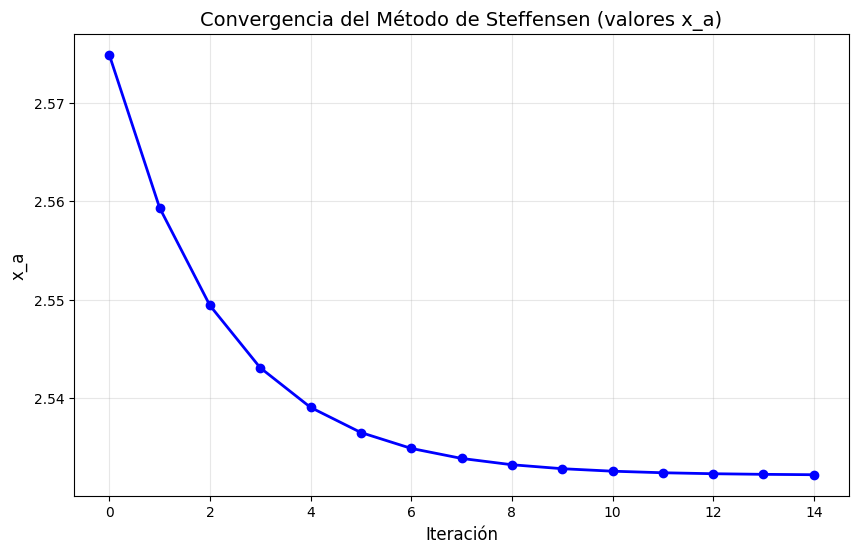

Valor final de convergencia: x_a = 2.5321537858


In [52]:
import matplotlib.pyplot as plt

# Graficar los valores de x_a (columna 'xs') del dataframe final
plt.figure(figsize=(10, 6))
plt.plot(range(len(ejemplo)), ejemplo['xa'], 'b-o', linewidth=2, markersize=6)
plt.title('Convergencia del Método de Steffensen (valores x_a)', fontsize=14)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('x_a', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f'Valor final de convergencia: x_a = {ejemplo["xa"].iloc[-1]:.10f}')

### Método de Steffensen
___

Comenzamos realizando una sucesión de **punto fijo** que tiene _orden lineal_ y luego aplicamos **Aitken** que nos permite alcanzar una convergencia mayor:

$$ \hat{x}^0 = x_0-\frac{(x_{1}-x_0)^{2}}{x_{2}-2x_{1}+x_0} $$

donde $x_0$ es el valor inicial, y luego se obtienen por punto fijo: $x_1=g(x_0)$ y $x_2=g(x_1)$.

El método de **Steffensen** propone utilizar la información ya obtenida por Aitken y realizarle punto fijo a ese valor.
Por lo tanto la próxima iteración sería:

donde $\hat{x}^0$ es el valor inicial, y por lo tanto definimos luego $\hat{x}_1=\hat{x}^0$, $\hat{x}_2=g(\hat{x}_1)$ y $\hat{x}_3=g(\hat{x}_2)$. Por lo tanto la próxima iteración sería: 

$$ \hat{x}^1 = \hat{x}_1-\frac{(\hat{x}_{2}-\hat{x}_1)^{2}}{\hat{x}_{3}-2\hat{x}_{2}+\hat{x}_1} $$

¿Hasta cuándo iteramos? Hasta que el **criterio de corte** alcance la **tolerancia**.
Es importante mencionar que el criterio de corte se realiza sobre la iteración de Aitken, que hemos llamado $ \hat{x}^n $




In [53]:
import numpy as np #librería para operaciones algebraicas y numéricas
import pandas as pd #librería para manejo de datos

#programo el método Steffensen
def steffensen(x0 , tol, itmax = 100): 
        df = pd.DataFrame(columns=('x0','x1','x2','a0'))
        contador = 0
        x0 = x0 
        x1 = g(x0)
        x2 = g(x1)
        xa= x0 -((x1-x0)**2)/(x2-2*x1+x0)
        dif=2*tolerancia
        while (contador < itmax) and (dif > tol):
            df.loc[contador] = [x0,x1,x2,xa]
            x0=xa
            x1 = g(x0)
            x2 = g(x1)
            xa = x0 -((x1-x0)**2)/(x2-2*x1+x0) 
            contador += 1 
            dif=abs((xa - x0) / xa) #lo que comparo son iteraciones de Aitken
        print('El método de Steffensen convergió en',contador,'iteraciones')
        return df



In [63]:
#defino el valor inicial y la tolerancia
X0=3
tolerancia=10**(-5)

def f(x):#definimos la función con la que vamos a trabajar
    return x**3-3*x**2+3   #deben cambiar la función si quieren probar otra 

def g(x):#definimos la función g 
    return (3*x**2-3)**(1/3)   # deben cambiar la función si quieren probar otra 

ejemplo2=steffensen(X0, tolerancia)

El método de Steffensen convergió en 3 iteraciones


In [65]:
from IPython.display import display, Math
import sympy.printing as printing

xcero = ejemplo2.x0
xuno = ejemplo2.x1
xdos = ejemplo2.x2
xa = ejemplo2.a0

print ("Analicemos las primeras iteraciones. \n")  

print ("Iteración "+str(0)+": ")
ec = "x_"+str(0)+"= "+str(xcero[0])+"\;, \\ x_"+str(0+1)+"= g(x_"+str(0)+")= "+str(xuno[0])+"\;y\; x_"+str(0+2)+"= g(x_"+str(0+1)+")= "+str(xdos[0])
ec2= "\hat{x}^"+str(0)+ "=x_"+str(0)+"- \\frac{(x_"+str(0+1)+"-x_"+str(0)+")^{2}}{x_"+str(0+2)+"-2x_"+str(0+1)+"+x_"+str(0)+"}= "+str(xa[0])
display(Math(printing.latex(ec,mul_symbol='dot')))
display(Math(printing.latex(ec2,mul_symbol='dot')))

for p in range (1,3):
    print ("Iteración "+str(p)+": ")
    ec = "\hat{x}_"+str(p)+"= \hat{x}^"+str(p-1)+"= "+str(xcero[p])+", \; \hat{x}_"+str(p+1)+"= g(\hat{x}_"+str(p)+")= "+str(xuno[p])+"\;y\; \hat{x}_"+str(p+2)+"= g(\hat{x}_"+str(p+1)+")= "+str(xdos[p])
    ec2= "\hat{x}^"+str(p)+ "=\hat{x}_"+str(p)+"- \\frac{(\hat{x}_"+str(p+1)+"-\hat{x}_"+str(p)+")^{2}}{\hat{x}_"+str(p+2)+"-2\hat{x}_"+str(p+1)+"+\hat{x}_"+str(p)+"}= "+str(xa[p])
    display(Math(printing.latex(ec,mul_symbol='dot')))
    display(Math(printing.latex(ec2,mul_symbol='dot')))


Analicemos las primeras iteraciones. 

Iteración 0: 


<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\;'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\;'
<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:20: SyntaxWarning: invalid escape sequence '\h'
<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:12: SyntaxWarning: invalid escape sequence '\;'
<>:13: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid e

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Iteración 1: 


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Iteración 2: 


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [61]:
print('Resumen de resultados para Steffensen:')
print('A continuación se muestran las primeras iteraciones:')
ejemplo2.columns= ['xi','xi+1','x+2','xs']
ejemplo2.head(10)

Resumen de resultados para Steffensen:
A continuación se muestran las primeras iteraciones:


,xi,xi+1,x+2,xs
0,3.000000,2.884499,2.800383,2.574936
1,2.574936,2.565769,2.558590,2.532675
2,2.532675,2.532552,2.532455,2.532089


![Curso Schwarz-Sosa-Suriano](http://www.fi.uba.ar/sites/default/files/logo.png)



# GRACIAS POR SU ATENCIÓN



### Ecuaciones no Lineales - Cuarta Parte

***

**Curso Schwarz - Sosa - Suriano**
- Métodos Numéricos. *Curso 2*
- Análisis Numérico I. *Curso 4*
- Métodos Matemáticos y Numéricos. *Curso 6*

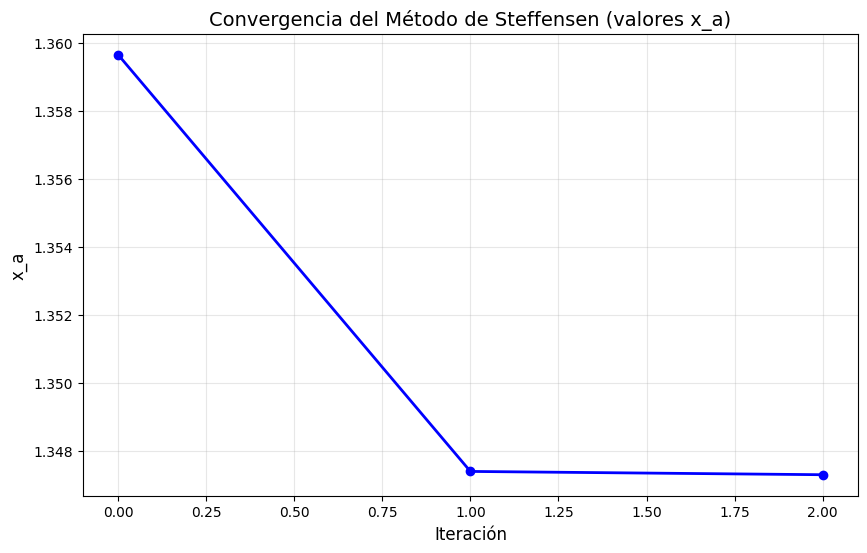

Valor final de convergencia: x_a = 1.3472963614


In [57]:
import matplotlib.pyplot as plt

# Graficar los valores de x_a (columna 'xs') del dataframe final
plt.figure(figsize=(10, 6))
plt.plot(range(len(ejemplo2)), ejemplo2['xs'], 'b-o', linewidth=2, markersize=6)
plt.title('Convergencia del Método de Steffensen (valores x_a)', fontsize=14)
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('x_a', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print(f'Valor final de convergencia: x_a = {ejemplo2["xs"].iloc[-1]:.10f}')